# Analisis Visualisasi Perbandingan Jenis Wisata di Delapan Kota: Tren Kunjungan, Popularitas, dan Wishlist Pengunjung

**Anggota Kelompok:**
1. Raid Muhammad Naufal (122450027)
2. Khusnun Nisa 		(122450078)
3. Elisabeth Claudia S. (122450123)

## Import Library

In [169]:
import pandas as pd
import numpy as np
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Dataset dan Menggabungkan Data

### Import POI List

Buda = Budapest\
Delh = Delhi\
Edin = Edinburgh\
Glas = Glasgow\
Osak = Osaka\
Pert = Perth\
Toro = Toronto\
Vien = Vienna

In [170]:
# Import semua dataset POI List untuk ke delapan kota
POI_Buda = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Buda.csv', sep=';')
POI_Delh = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Delh.csv', sep=';')
POI_Edin = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Edin.csv', sep=';')
POI_Glas = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Glas.csv', sep=';')
POI_Osak = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Osak.csv', sep=';')
POI_Pert = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Pert.csv', sep=';')
POI_Toro = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Toro.csv', sep=';')
POI_Vien = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/poiList-ijcai15/POI-Vien.csv', sep=';')

In [171]:
POI_Buda.head()

,poiID,poiName,lat,long,theme
0,1,S%C3%A1ndor_Palace,47.497800,19.037800,Historical
1,2,Ervin_Szab%C3%B3_Library,47.489378,19.064800,Historical
2,3,Gresham_Palace,47.499747,19.047981,Historical
3,4,Buda_Castle,47.496110,19.039720,Historical
4,5,Hungarian_State_Opera_House,47.502808,19.058189,Cultural


In [172]:
POI_Delh.head()

,poiID,poiName,lat,long,theme
0,1,India_Gate,28.612864,77.229306,Building
1,2,Sansad_Bhavan,28.617189,77.208084,Building
2,3,Rashtrapati_Bhavan,28.614342,77.199803,Building
3,4,"Connaught_Place,_New_Delhi",28.632780,77.219720,Park
4,5,Lodhi_Gardens,28.593000,77.220000,Park


In [173]:
POI_Edin.head()

,poiID,poiName,lat,long,theme
0,1,Edinburgh_Castle,55.948611,-3.200833,Historical
1,2,Holyrood_Palace,55.952500,-3.172500,Historical
2,3,National_Museum_of_Scotland,55.946940,-3.190000,Museum
3,4,Scottish_Parliament_Building,55.952158,-3.175204,Structure
4,5,Forth_Rail_Bridge,56.000421,-3.388726,Structure


In [174]:
POI_Glas.head()

,poiID,poiName,lat,long,theme
0,1,Glasgow_Central_railway_station,55.85800,-4.25800,Transport
1,2,Glasgow_Queen_Street_railway_station,55.86220,-4.25120,Transport
2,3,Glasgow_Airport,55.87194,-4.43306,Transport
3,4,Glasgow_Prestwick_International_Airport,55.50944,-4.59444,Transport
4,5,Clyde_Tunnel,55.86867,-4.33115,Transport


In [175]:
POI_Osak.head()

,poiID,poiName,lat,long,theme
0,1,Osaka_Aquarium_Kaiyukan,34.654472,135.428889,Amusement
1,2,Tempozan_Ferris_Wheel,34.656166,135.431031,Amusement
2,3,Tenn%C5%8Dji_Zoo,34.652556,135.508496,Amusement
3,4,Universal_Studios_Japan,34.664720,135.433060,Amusement
4,5,HEP_Five,34.704003,135.500447,Amusement


In [176]:
POI_Pert.head()

,poiID,poiName,lat,long,theme
0,1,Perth_Town_Hall,-31.955000,115.860556,Structure
1,2,"Parliament_House,_Perth",-31.951634,115.847209,Structure
2,3,State_Library_of_Western_Australia,-31.949031,115.860513,Structure
3,4,"Chinatown,_Perth",-31.946000,115.854000,Precinct
4,5,"Northbridge,_Western_Australia",-31.946000,115.854000,Precinct


In [177]:
POI_Toro.head()

,poiID,poiName,lat,long,theme
0,1,Air_Canada_Centre,43.643330,-79.379170,Sport
1,2,BMO_Field,43.632780,-79.418610,Sport
2,3,Maple_Leaf_Gardens,43.662220,-79.380280,Sport
3,4,Rogers_Centre,43.641390,-79.389170,Sport
4,5,Woodbine_Racetrack,43.712525,-79.602042,Sport


In [178]:
POI_Vien.head()

,poiID,poiName,lat,long,theme
0,1,Sch%C3%B6nbrunn_Palace,48.184516,16.311865,Palace
1,2,Tiergarten_Sch%C3%B6nbrunn,48.182220,16.302500,Zoo
2,3,Wiener_Riesenrad,48.216651,16.395949,Entertainment
3,4,"Albertina,_Vienna",48.204440,16.367780,Museum
4,5,Hofburg_Palace,48.206507,16.365262,Palace


### Deskripsi Dataset POI List

In [179]:
def count_unique_values(df):
  print(f"\nNumber of rows: {df.shape[0]}")
  print(f"Number of columns: {df.shape[1]}")
  print(f"Column names: {df.columns.tolist()}")
  for col in df.columns:
    print(f"Column '{col}': {df[col].nunique()} unique values")


count_unique_values(POI_Buda)
count_unique_values(POI_Delh)
count_unique_values(POI_Edin)
count_unique_values(POI_Glas)
count_unique_values(POI_Osak)
count_unique_values(POI_Pert)
count_unique_values(POI_Toro)
count_unique_values(POI_Vien)


Number of rows: 39
Number of columns: 5
Column names: ['poiID', 'poiName', 'lat', 'long', 'theme']
Column 'poiID': 39 unique values
Column 'poiName': 39 unique values
Column 'lat': 37 unique values
Column 'long': 38 unique values
Column 'theme': 6 unique values

Number of rows: 26
Number of columns: 5
Column names: ['poiID', 'poiName', 'lat', 'long', 'theme']
Column 'poiID': 26 unique values
Column 'poiName': 26 unique values
Column 'lat': 26 unique values
Column 'long': 26 unique values
Column 'theme': 6 unique values

Number of rows: 29
Number of columns: 5
Column names: ['poiID', 'poiName', 'lat', 'long', 'theme']
Column 'poiID': 29 unique values
Column 'poiName': 29 unique values
Column 'lat': 28 unique values
Column 'long': 28 unique values
Column 'theme': 6 unique values

Number of rows: 29
Number of columns: 5
Column names: ['poiID', 'poiName', 'lat', 'long', 'theme']
Column 'poiID': 29 unique values
Column 'poiName': 29 unique values
Column 'lat': 28 unique values
Column 'long

In [180]:
POI_Osak

,poiID,poiName,lat,long,theme
0,1,Osaka_Aquarium_Kaiyukan,34.654472,135.428889,Amusement
1,2,Tempozan_Ferris_Wheel,34.656166,135.431031,Amusement
2,3,Tenn%C5%8Dji_Zoo,34.652556,135.508496,Amusement
3,4,Universal_Studios_Japan,34.664720,135.433060,Amusement
4,5,HEP_Five,34.704003,135.500447,Amusement
5,6,Umeda_Sky_Building,34.705280,135.489720,Amusement
6,7,Nakanoshima_Park,34.693056,135.506431,Park
7,8,Osaka_Castle,34.687220,135.525830,Park
8,9,Sumiyoshi_Park,34.612400,135.488480,Park
9,10,Tenn%C5%8Dji_Park,34.649850,135.511110,Park


In [181]:
POI_Osak['poiName'].value_counts()

,count
poiName,
Osaka_Castle,2
Osaka_Aquarium_Kaiyukan,1
Tamatsukuri_Inari_Shrine,1
"Doyama,_Osaka,_Japan",1
Zepp,1
Ky%C5%8Dbashi#Osaka,1
J%C5%ABs%C5%8D,1
Amerikamura,1
Nipponbashi,1


### Import User Visits

In [182]:
# Import semua dataset User Visits pada delapan kota
user_visits_Buda = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Buda-allPOI.csv', sep=';')
user_visits_Delh = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Delh-allPOI.csv', sep=';')
user_visits_Edin = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Edin.csv', sep=';')
user_visits_Glas = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Glas.csv', sep=';')
user_visits_Osak = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Osak.csv', sep=';')
user_visits_Pert = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Pert-allPOI.csv', sep=';')
user_visits_Toro = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Toro.csv', sep=';')
user_visits_Vien = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/userVisits-ijcai15/userVisits-Vien-allPOI.csv', sep=';')

### Deskripsi Dataset User Visits

In [183]:
user_visits_Buda.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,5528931997,10088550@N00,1299815700,14,Transport,450,1
1,3563396553,10131865@N02,1243168517,29,Museum,587,2
2,3564212768,10131865@N02,1243168542,29,Museum,587,2
3,9800881585,101655764@N06,1370007538,3,Historical,859,3
4,12542876345,101655764@N06,1370008356,14,Transport,450,3


In [184]:
user_visits_Delh.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,8636126004,10126637@N02,1365314352,12,Architectural,709,1
1,8635021631,10126637@N02,1365314896,11,Architectural,418,1
2,7133494159,10216976@N05,1332119449,18,Religious,534,2
3,7133492891,10216976@N05,1332119539,18,Religious,534,2
4,7909379802,10297667@N06,1255940392,18,Religious,534,3


In [185]:
user_visits_Edin.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,355803498,10063645@N00,1168492531,17,Structure,1303,1
1,355803564,10063645@N00,1168492549,17,Structure,1303,1
2,355803639,10063645@N00,1168492558,17,Structure,1303,1
3,1431486935,10091295@N02,1190421746,12,Cultural,1208,2
4,1432364530,10091295@N02,1190421792,12,Cultural,1208,2


In [186]:
user_visits_Glas.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,268535960,10063645@N00,1160716026,11,Education,1008,1
1,284505324,10063645@N00,1162247008,2,Transport,916,2
2,285538933,10063645@N00,1162333588,11,Education,1008,3
3,289494173,10063645@N00,1162693595,16,Shopping,848,4
4,289494204,10063645@N00,1162693817,21,Museum,618,4


In [187]:
user_visits_Osak.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,6656416589,10297518@N00,1277719324,20,Entertainment,514,1
1,6656418463,10297518@N00,1277719344,20,Entertainment,514,1
2,6656420371,10297518@N00,1277719541,20,Entertainment,514,1
3,6656421479,10297518@N00,1277719558,20,Entertainment,514,1
4,6656422763,10297518@N00,1277719573,20,Entertainment,514,1


In [188]:
user_visits_Pert.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,7158915820,11146442@N00,1336155672,1,Structure,256,1
1,7158914400,11146442@N00,1336156397,7,Park,329,1
2,7158907712,11146442@N00,1336157902,7,Park,329,1
3,7158905954,11146442@N00,1336158437,6,Park,500,1
4,7158899778,11146442@N00,1336170989,23,Entertainment,128,1


In [189]:
user_visits_Toro.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,7941504100,10007579@N00,1346844688,30,Structure,1538,1
1,4886005532,10012675@N05,1142731848,6,Cultural,986,2
2,4886006468,10012675@N05,1142732248,6,Cultural,986,2
3,4885404441,10012675@N05,1142732373,6,Cultural,986,2
4,4886008334,10012675@N05,1142732445,6,Cultural,986,2


In [190]:
user_visits_Vien.head()

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID
0,8703140158,10002536@N02,1367146438,8,Structure,571,1
1,8703142404,10002536@N02,1367146924,8,Structure,571,1
2,8703142278,10002536@N02,1367147103,8,Structure,571,1
3,8702020493,10002536@N02,1367147154,8,Structure,571,1
4,3074192212,10014440@N06,1227393491,5,Palace,1750,2


In [191]:
count_unique_values(user_visits_Buda)
count_unique_values(user_visits_Delh)
count_unique_values(user_visits_Edin)
count_unique_values(user_visits_Glas)
count_unique_values(user_visits_Osak)
count_unique_values(user_visits_Pert)
count_unique_values(user_visits_Toro)
count_unique_values(user_visits_Vien)


Number of rows: 18513
Number of columns: 7
Column names: ['photoID', 'userID', 'dateTaken', 'poiID', 'poiTheme', 'poiFreq', 'seqID']
Column 'photoID': 18513 unique values
Column 'userID': 935 unique values
Column 'dateTaken': 18094 unique values
Column 'poiID': 38 unique values
Column 'poiTheme': 6 unique values
Column 'poiFreq': 37 unique values
Column 'seqID': 2361 unique values

Number of rows: 3993
Number of columns: 7
Column names: ['photoID', 'userID', 'dateTaken', 'poiID', 'poiTheme', 'poiFreq', 'seqID']
Column 'photoID': 3993 unique values
Column 'userID': 279 unique values
Column 'dateTaken': 3920 unique values
Column 'poiID': 23 unique values
Column 'poiTheme': 6 unique values
Column 'poiFreq': 22 unique values
Column 'seqID': 489 unique values

Number of rows: 33944
Number of columns: 7
Column names: ['photoID', 'userID', 'dateTaken', 'poiID', 'poiTheme', 'poiFreq', 'seqID']
Column 'photoID': 33944 unique values
Column 'userID': 1454 unique values
Column 'dateTaken': 33229 

### Import Cost Prof

In [192]:
cost_prof_Buda = pd.read_csv('/content/drive/MyDrive/Tubes/VDI/data-ijcai15/costProf-ijcai15/costProfCat-BudaPOI-all.csv', sep=';')

cost_prof_Buda

,from,to,cost,profit,category
0,1,2,2236.791812,83,Historical
1,1,3,795.755249,859,Historical
2,1,4,237.161458,895,Historical
3,1,5,1631.576376,552,Cultural
4,1,6,2303.468537,472,Museum
...,...,...,...,...,...
1401,39,34,4528.343305,2,Park
1402,39,35,1228.431865,192,Park
1403,39,36,10387.524535,894,Museum
1404,39,37,1690.465458,785,Transport


## Data Preprocessing

### Menggabungkan POI List Masing-Masing Kota

In [193]:
# Membuat list untuk menyimpan seluruh dataframe POI List
dfs = [POI_Buda, POI_Delh, POI_Edin, POI_Glas, POI_Osak, POI_Pert, POI_Toro, POI_Vien]

# Membuat list untuk menyimpan nama-nama kota
cities = ['Budapest', 'Delhi', 'Edinburgh', 'Glasgow', 'Osaka', 'Perth', 'Toronto', 'Vienna']

# Membuat list kosong untuk menyimpan data gabungan
combined_data = []

# Perulangan berdasarkan dataframe dan nama kota
for i, df in enumerate(dfs):
    # Menambahkan kolom 'city' ke dataframe
    df['city'] = cities[i]
    # Menambahkan dataframe dengan nama kota ke list data gabungan
    combined_data.append(df)

# Menggabungkan dataframe dalam list data gabungan menjadi satu dataframe
POI_List = pd.concat(combined_data, ignore_index=True)

# Menampilkan sample dari dataframe
POI_List.sample(20)

,poiID,poiName,lat,long,theme,city
49,11,Qutub_Minar,28.524355,77.185248,Architectural,Delhi
79,15,Royal_Scottish_Academy_Building,55.951750,-3.196389,Structure,Edinburgh
95,2,Glasgow_Queen_Street_railway_station,55.862200,-4.251200,Transport,Glasgow
146,24,Amerikamura,34.672086,135.497960,Entertainment,Osaka
48,10,Safdarjung%27s_Tomb,28.589266,77.210506,Architectural,Delhi
120,27,Pollok_House,55.827928,-4.318222,Structure,Glasgow
187,11,Royal_Ontario_Museum,43.667500,-79.394170,Cultural,Toronto
160,9,"Russell_Square,_Perth",-31.946100,115.855500,Park,Perth
226,20,"St._Charles%27s_Church,_Vienna",48.198333,16.371389,Historical,Vienna
126,4,Universal_Studios_Japan,34.664720,135.433060,Amusement,Osaka


In [194]:
# Filter data dengan POI ID 1 dan 2
filtered_data = POI_List[POI_List['poiID'].isin([1, 2])]

filtered_data

,poiID,poiName,lat,long,theme,city
0,1,S%C3%A1ndor_Palace,47.497800,19.037800,Historical,Budapest
1,2,Ervin_Szab%C3%B3_Library,47.489378,19.064800,Historical,Budapest
39,1,India_Gate,28.612864,77.229306,Building,Delhi
40,2,Sansad_Bhavan,28.617189,77.208084,Building,Delhi
65,1,Edinburgh_Castle,55.948611,-3.200833,Historical,Edinburgh
66,2,Holyrood_Palace,55.952500,-3.172500,Historical,Edinburgh
94,1,Glasgow_Central_railway_station,55.858000,-4.258000,Transport,Glasgow
95,2,Glasgow_Queen_Street_railway_station,55.862200,-4.251200,Transport,Glasgow
123,1,Osaka_Aquarium_Kaiyukan,34.654472,135.428889,Amusement,Osaka
124,2,Tempozan_Ferris_Wheel,34.656166,135.431031,Amusement,Osaka


In [195]:
POI_List.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   poiID    236 non-null    int64  
 1   poiName  236 non-null    object 
 2   lat      236 non-null    float64
 3   long     236 non-null    float64
 4   theme    236 non-null    object 
 5   city     236 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 11.2+ KB


In [196]:
POI_List.head(10)

,poiID,poiName,lat,long,theme,city
0,1,S%C3%A1ndor_Palace,47.497800,19.037800,Historical,Budapest
1,2,Ervin_Szab%C3%B3_Library,47.489378,19.064800,Historical,Budapest
2,3,Gresham_Palace,47.499747,19.047981,Historical,Budapest
3,4,Buda_Castle,47.496110,19.039720,Historical,Budapest
4,5,Hungarian_State_Opera_House,47.502808,19.058189,Cultural,Budapest
5,6,House_of_Terror,47.506940,19.065280,Museum,Budapest
6,7,National_Sz%C3%A9ch%C3%A9nyi_Library,47.495000,19.039170,Historical,Budapest
7,8,Matthias_Church,47.501940,19.034170,Cultural,Budapest
8,9,Fisherman%27s_Bastion,47.501670,19.035000,Historical,Budapest
9,10,City_Park_(Budapest),47.513890,19.084720,Park,Budapest


### Decoding poiName

In [197]:
# Decode URL-encoded values dalam kolom 'poiName'
POI_List['poiName'] = POI_List['poiName'].apply(lambda x: urllib.parse.unquote(x))

POI_List.head(10)

,poiID,poiName,lat,long,theme,city
0,1,Sándor_Palace,47.497800,19.037800,Historical,Budapest
1,2,Ervin_Szabó_Library,47.489378,19.064800,Historical,Budapest
2,3,Gresham_Palace,47.499747,19.047981,Historical,Budapest
3,4,Buda_Castle,47.496110,19.039720,Historical,Budapest
4,5,Hungarian_State_Opera_House,47.502808,19.058189,Cultural,Budapest
5,6,House_of_Terror,47.506940,19.065280,Museum,Budapest
6,7,National_Széchényi_Library,47.495000,19.039170,Historical,Budapest
7,8,Matthias_Church,47.501940,19.034170,Cultural,Budapest
8,9,Fisherman's_Bastion,47.501670,19.035000,Historical,Budapest
9,10,City_Park_(Budapest),47.513890,19.084720,Park,Budapest


In [198]:
POI_List.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   poiID    236 non-null    int64  
 1   poiName  236 non-null    object 
 2   lat      236 non-null    float64
 3   long     236 non-null    float64
 4   theme    236 non-null    object 
 5   city     236 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 11.2+ KB


### Menggabungkan User Visit Masing-Masing Kota

In [199]:
# Membuat list untuk menyimpan seluruh dataframe user visits
users = [user_visits_Buda, user_visits_Delh, user_visits_Edin, user_visits_Glas, user_visits_Osak, user_visits_Pert, user_visits_Toro, user_visits_Vien]

# Membuat list untuk menyimpan nama-nama kota
cities = ['Budapest', 'Delhi', 'Edinburgh', 'Glasgow', 'Osaka', 'Perth', 'Toronto', 'Vienna']

# Membuat list kosong untuk menyimpan data gabungan
combined_data = []

# Perulangan berdasarkan dataframe dan nama kota
for i, df in enumerate(users):
    # Menambahkan kolom 'city' ke dataframe
    df['city'] = cities[i]
    # Menambahkan dataframe dengan nama kota ke list data gabungan
    combined_data.append(df)

# Menggabungkan dataframe dalam list data gabungan menjadi satu dataframe
user_visits = pd.concat(combined_data, ignore_index=True)

# Menampilkan sample dari dataframe
user_visits.sample(20)

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID,city
60698,1842890790,27793158@N00,1041441246,28,Structure,439,511,Glasgow
1749,5555996719,14878709@N00,1300592318,5,Cultural,552,180,Budapest
115247,7953785372,86822950@N03,1346844051,4,Sport,3056,5447,Toronto
77479,10332794533,56089141@N07,1381558189,6,Park,500,344,Perth
78700,4334378251,76135747@N00,1265454325,13,Cultural,412,563,Perth
8188,8268271218,39523645@N00,1355269588,9,Historical,946,944,Budapest
130924,7067246581,31403562@N00,1332932685,17,Historical,5533,1045,Vienna
29972,85764027,24645033@N00,1086522810,10,Park,845,1175,Edinburgh
131134,6920008524,31403562@N00,1334072762,17,Historical,5533,1048,Vienna
80813,8487246921,12316147@N05,1361145057,16,Amusement,3553,236,Toronto


In [200]:
# Memfilter data dengan menampilkan 2 data teratas untuk setiap kota
filtered_data = user_visits.groupby('city').head(2)

filtered_data

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID,city
0,5528931997,10088550@N00,1299815700,14,Transport,450,1,Budapest
1,3563396553,10131865@N02,1243168517,29,Museum,587,2,Budapest
18513,8636126004,10126637@N02,1365314352,12,Architectural,709,1,Delhi
18514,8635021631,10126637@N02,1365314896,11,Architectural,418,1,Delhi
22506,355803498,10063645@N00,1168492531,17,Structure,1303,1,Edinburgh
22507,355803564,10063645@N00,1168492549,17,Structure,1303,1,Edinburgh
56450,268535960,10063645@N00,1160716026,11,Education,1008,1,Glasgow
56451,284505324,10063645@N00,1162247008,2,Transport,916,2,Glasgow
67884,6656416589,10297518@N00,1277719324,20,Entertainment,514,1,Osaka
67885,6656418463,10297518@N00,1277719344,20,Entertainment,514,1,Osaka


In [201]:
user_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153208 entries, 0 to 153207
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   photoID    153208 non-null  int64 
 1   userID     153208 non-null  object
 2   dateTaken  153208 non-null  int64 
 3   poiID      153208 non-null  int64 
 4   poiTheme   153208 non-null  object
 5   poiFreq    153208 non-null  int64 
 6   seqID      153208 non-null  int64 
 7   city       153208 non-null  object
dtypes: int64(5), object(3)
memory usage: 9.4+ MB


In [202]:
user_visits[(user_visits['city'] == 'Osaka') & (user_visits['poiID'] == 1)]

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID,city
67920,8657549120,10340578@N06,1364432096,1,Amusement,886,4,Osaka
67958,13502349575,115391424@N05,1395539024,1,Amusement,886,11,Osaka
67959,13502349605,115391424@N05,1395539027,1,Amusement,886,11,Osaka
67960,13502693544,115391424@N05,1395539028,1,Amusement,886,11,Osaka
67961,13502349855,115391424@N05,1395539029,1,Amusement,886,11,Osaka
...,...,...,...,...,...,...,...,...
75588,5101631973,97972855@N00,1287600841,1,Amusement,886,1104,Osaka
75589,5102252342,97972855@N00,1287601780,1,Amusement,886,1104,Osaka
75590,5102271906,97972855@N00,1287602426,1,Amusement,886,1104,Osaka
75591,5101702747,97972855@N00,1287603192,1,Amusement,886,1104,Osaka


poiFreq sama dengan Frekuensi suatu poi dikunjungi. 886 = 886.

### Menambahkan Kolom poiFreq ke dalam Dataframe POI_List

In [203]:
# Memfilter nilai poiFreq berdasarkan city dan poiID
def get_poi_freq(city, poi_id):
    # Mengambil nilai poiFreq untuk kombinasi city dan poiID tertentu
    freq = user_visits[(user_visits['city'] == city) & (user_visits['poiID'] == poi_id)]['poiFreq']
    return freq.values[0] if not freq.empty else 0  # Jika tidak ditemukan, kembalikan nilai 0

# Menambahkan nilai poiFreq ke dalam dataframe POI_List
POI_List['poiFreq'] = POI_List.apply(lambda row: get_poi_freq(row['city'], row['poiID']), axis=1)

# Menampilkan sampel data
POI_List.head(10)

,poiID,poiName,lat,long,theme,city,poiFreq
0,1,Sándor_Palace,47.497800,19.037800,Historical,Budapest,1020
1,2,Ervin_Szabó_Library,47.489378,19.064800,Historical,Budapest,83
2,3,Gresham_Palace,47.499747,19.047981,Historical,Budapest,859
3,4,Buda_Castle,47.496110,19.039720,Historical,Budapest,895
4,5,Hungarian_State_Opera_House,47.502808,19.058189,Cultural,Budapest,552
5,6,House_of_Terror,47.506940,19.065280,Museum,Budapest,472
6,7,National_Széchényi_Library,47.495000,19.039170,Historical,Budapest,305
7,8,Matthias_Church,47.501940,19.034170,Cultural,Budapest,1584
8,9,Fisherman's_Bastion,47.501670,19.035000,Historical,Budapest,946
9,10,City_Park_(Budapest),47.513890,19.084720,Park,Budapest,152


In [204]:
POI_List.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   poiID    236 non-null    int64  
 1   poiName  236 non-null    object 
 2   lat      236 non-null    float64
 3   long     236 non-null    float64
 4   theme    236 non-null    object 
 5   city     236 non-null    object 
 6   poiFreq  236 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 13.0+ KB


#### Membandingkan poiFreq pada dataframe POI_List dengan Data Sebenarnya (user_visits)

In [205]:
POI_List[(POI_List['city'] == 'Osaka') & (POI_List['poiID'] == 27)]

,poiID,poiName,lat,long,theme,city,poiFreq
149,27,Zepp,34.657361,135.501306,Entertainment,Osaka,3


In [206]:
user_visits[(user_visits['city'] == 'Osaka') & (user_visits['poiID'] == 27)]

,photoID,userID,dateTaken,poiID,poiTheme,poiFreq,seqID,city
68072,6619939051,12452841@N00,1325022901,27,Entertainment,3,21,Osaka
68724,9739979702,22896220@N05,1378607535,27,Entertainment,3,114,Osaka
69844,5342312561,40037997@N02,1294620713,27,Entertainment,3,381,Osaka


### Menghitung Kategori POI untuk Setiap Kota

In [207]:
# Menghitung kategori POI pada setiap kota
poi_theme_city = POI_List.groupby(['city', 'theme']).size().unstack(fill_value=0)

poi_theme_city

theme,Amusement,Architectural,Beach,Building,Cultural,Education,Entertainment,Historical,Museum,Palace,Park,Precinct,Religion,Religious,Shopping,Sport,Structure,Transport,Zoo
city,,,,,,,,,,,,,,,,,,,
Budapest,0,0,0,0,6,0,0,9,8,0,10,0,0,0,2,0,0,4,0
Delhi,0,8,0,3,0,0,0,0,2,0,4,1,0,8,0,0,0,0,0
Edinburgh,0,0,0,0,3,0,1,5,4,0,4,0,0,0,0,0,12,0,0
Glasgow,0,0,0,0,0,6,0,0,4,0,2,0,2,0,2,0,7,6,0
Osaka,6,0,0,0,0,0,11,6,0,0,6,0,0,0,0,0,0,0,0
Perth,0,0,2,0,2,0,3,0,0,0,6,2,0,0,0,2,3,5,0
Toronto,5,0,4,0,8,0,0,0,0,0,0,0,0,0,5,5,3,0,0
Vienna,0,0,0,0,1,0,2,6,11,4,2,0,0,0,0,0,1,0,2


In [208]:
poi_theme_city.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, Budapest to Vienna
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Amusement      8 non-null      int64
 1   Architectural  8 non-null      int64
 2   Beach          8 non-null      int64
 3   Building       8 non-null      int64
 4   Cultural       8 non-null      int64
 5   Education      8 non-null      int64
 6   Entertainment  8 non-null      int64
 7   Historical     8 non-null      int64
 8   Museum         8 non-null      int64
 9   Palace         8 non-null      int64
 10  Park           8 non-null      int64
 11  Precinct       8 non-null      int64
 12  Religion       8 non-null      int64
 13  Religious      8 non-null      int64
 14  Shopping       8 non-null      int64
 15  Sport          8 non-null      int64
 16  Structure      8 non-null      int64
 17  Transport      8 non-null      int64
 18  Zoo            8 non-null      int64
dtypes: in

### Mencari Kategori POI Terbanyak pada Setiap Kota

In [209]:
# Menentukan nilai maksimum untuk setiap baris (kota)
max_values = poi_theme_city.max(axis=1)

# Menentukan kolom (kategori) dengan nilai maksimum di setiap baris
dominant_categories = poi_theme_city.apply(
    lambda row: list(row[row == max_values[row.name]].index), axis=1
)

# Membuat DataFrame untuk menyimpan hasil
dominant_categories_df = pd.DataFrame({
    'City': poi_theme_city.index,
    'Dominant Categories': dominant_categories
}).reset_index(drop=True)

# Menampilkan hasil
print(dominant_categories_df)

# Standarisasi kolom 'Dominant Categories'
dominant_categories_df['Dominant Categories'] = dominant_categories_df['Dominant Categories'].apply(
    lambda categories: ' & '.join(sorted(categories))
)

# Menampilkan hasil setelah standarisasi
print(dominant_categories_df)

        City         Dominant Categories
0   Budapest                      [Park]
1      Delhi  [Architectural, Religious]
2  Edinburgh                 [Structure]
3    Glasgow                 [Structure]
4      Osaka             [Entertainment]
5      Perth                      [Park]
6    Toronto                  [Cultural]
7     Vienna                    [Museum]
        City        Dominant Categories
0   Budapest                       Park
1      Delhi  Architectural & Religious
2  Edinburgh                  Structure
3    Glasgow                  Structure
4      Osaka              Entertainment
5      Perth                       Park
6    Toronto                   Cultural
7     Vienna                     Museum


## Visualisasi 1 (Stacked Bar)

In [210]:
# Menghitung persentase proposi kategori POI setiap kota
poi_theme_city_percentage = poi_theme_city.div(poi_theme_city.sum(axis=1), axis=0) * 100

poi_theme_city_percentage

theme,Amusement,Architectural,Beach,Building,Cultural,Education,Entertainment,Historical,Museum,Palace,Park,Precinct,Religion,Religious,Shopping,Sport,Structure,Transport,Zoo
city,,,,,,,,,,,,,,,,,,,
Budapest,0.000000,0.000000,0.000000,0.000000,15.384615,0.000000,0.000000,23.076923,20.512821,0.000000,25.641026,0.000000,0.000000,0.000000,5.128205,0.000000,0.000000,10.256410,0.000000
Delhi,0.000000,30.769231,0.000000,11.538462,0.000000,0.000000,0.000000,0.000000,7.692308,0.000000,15.384615,3.846154,0.000000,30.769231,0.000000,0.000000,0.000000,0.000000,0.000000
Edinburgh,0.000000,0.000000,0.000000,0.000000,10.344828,0.000000,3.448276,17.241379,13.793103,0.000000,13.793103,0.000000,0.000000,0.000000,0.000000,0.000000,41.379310,0.000000,0.000000
Glasgow,0.000000,0.000000,0.000000,0.000000,0.000000,20.689655,0.000000,0.000000,13.793103,0.000000,6.896552,0.000000,6.896552,0.000000,6.896552,0.000000,24.137931,20.689655,0.000000
Osaka,20.689655,0.000000,0.000000,0.000000,0.000000,0.000000,37.931034,20.689655,0.000000,0.000000,20.689655,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Perth,0.000000,0.000000,8.000000,0.000000,8.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,8.000000,0.000000,0.000000,0.000000,8.000000,12.000000,20.000000,0.000000
Toronto,16.666667,0.000000,13.333333,0.000000,26.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.666667,16.666667,10.000000,0.000000,0.000000
Vienna,0.000000,0.000000,0.000000,0.000000,3.448276,0.000000,6.896552,20.689655,37.931034,13.793103,6.896552,0.000000,0.000000,0.000000,0.000000,0.000000,3.448276,0.000000,6.896552


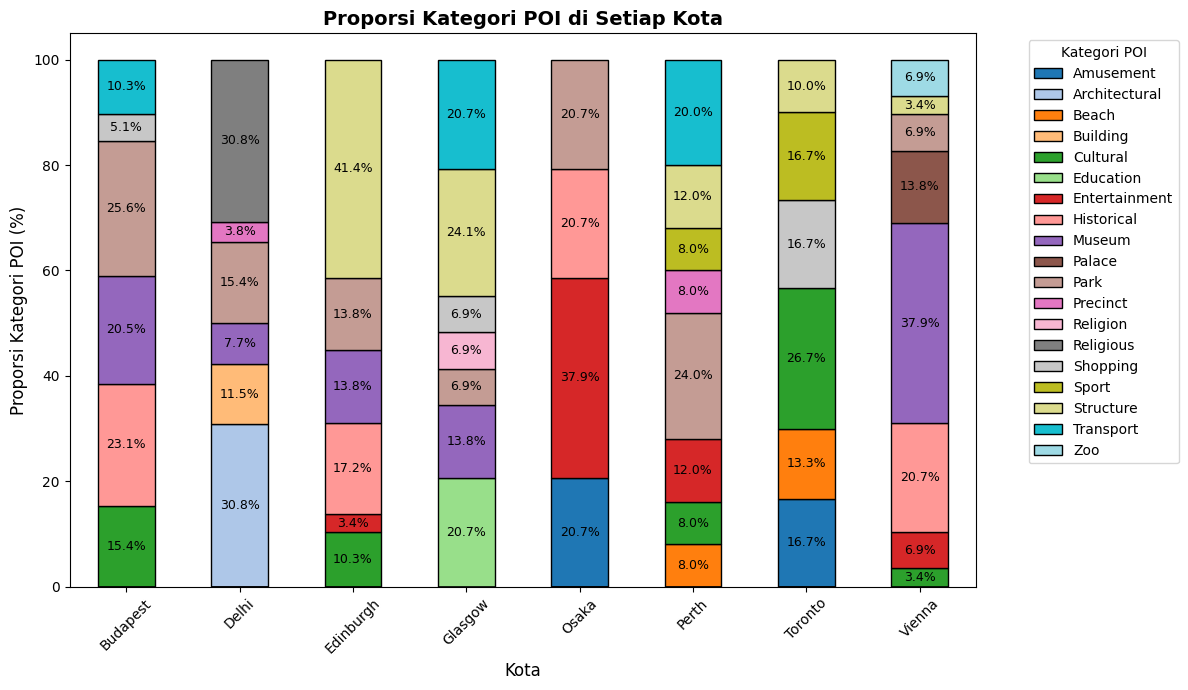

In [211]:
# Membuat visualisasi stacked bar
ax = poi_theme_city_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='tab20',  # Menggunakan colormap untuk warna kontras
    edgecolor='black'
)

# Menambahkan label, judul, dan lainnya
plt.title('Proporsi Kategori POI di Setiap Kota', fontsize=14, weight='bold')
plt.xlabel('Kota', fontsize=12)
plt.ylabel('Proporsi Kategori POI (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Kategori POI', bbox_to_anchor=(1.05, 1), loc='upper left')

# Menampilkan persentase nilai pada setiap segmen bar
for container in ax.containers:
    for bar in container:
        if bar.get_height() > 0:  # Hanya jika proporsi > 0
            height = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_y() + height / 2  # Posisi teks
            ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9)

# Menampilkan plot
plt.tight_layout()
plt.show()

## Visualisasi 2 (Entropy)

In [212]:
# Menghitung entropy untuk setiap kota
def calculate_entropy(row):
    proportions = row / row.sum()
    entropy = -np.nansum(proportions * np.log2(proportions + 1e-9))  # Menghindari log(0)
    return entropy

poi_theme_city["Entropy"] = poi_theme_city.apply(calculate_entropy, axis=1)

poi_theme_city["Entropy"]

,Entropy
city,
Budapest,2.432623
Delhi,2.286790
Edinburgh,2.258530
Glasgow,2.627945
Osaka,1.941323
Perth,2.858689
Toronto,2.520764
Vienna,2.528204


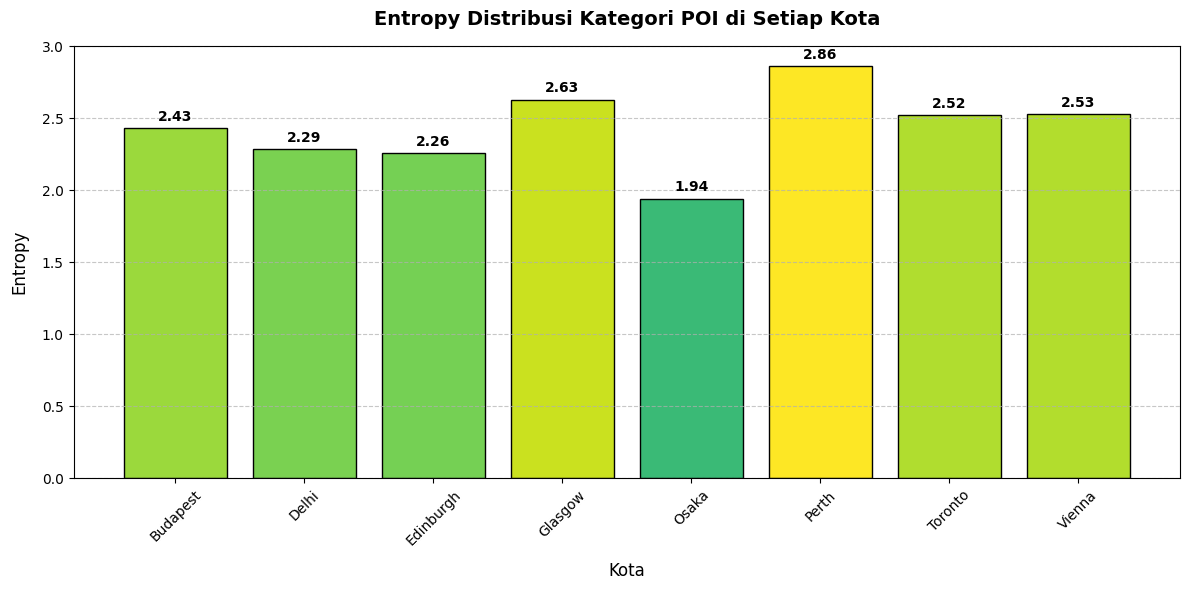

In [213]:
# Membuat warna gradasi berdasarkan nilai entropy
colors = plt.cm.viridis(poi_theme_city["Entropy"] / poi_theme_city["Entropy"].max())

# Membuat visualisasi entropy
plt.figure(figsize=(12, 6))
bars = plt.bar(poi_theme_city.index, poi_theme_city["Entropy"], color=colors, edgecolor='black')

# Menambahkan grid horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan anotasi nilai pada puncak setiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, f'{yval:.2f}', ha='center', fontsize=10, weight="bold")

# Menambahkan label dan judul
plt.xlabel("Kota", fontsize=12, labelpad=10)
plt.ylabel("Entropy", fontsize=12, labelpad=10)
plt.title("Entropy Distribusi Kategori POI di Setiap Kota", fontsize=14, pad=15, weight="bold")

# Menambahkan rotasi pada label sumbu x
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Menampilkan grafik
plt.show()

## Visualisasi 3 (Horizontal Bar Chart)

In [214]:
# Menghitung jumlah kunjungan per kota
poi_freq_by_city = POI_List.groupby('city')['poiFreq'].sum().sort_values(ascending=False)

poi_freq_by_city

,poiFreq
city,
Toronto,39466
Vienna,34530
Edinburgh,33944
Budapest,18513
Glasgow,11434
Osaka,7747
Delhi,3993
Perth,3643


In [215]:
# Menghitung distribusi kategori POI pada 3 kota teratas
top_3_cities = poi_freq_by_city.nlargest(3).index
top_cities_poi_theme = (
    POI_List[POI_List['city'].isin(top_3_cities)]
    .groupby(['city', 'theme'])['poiFreq']
    .sum()
    .reset_index()
)

top_cities_poi_theme

,city,theme,poiFreq
0,Edinburgh,Cultural,7020
1,Edinburgh,Entertainment,409
2,Edinburgh,Historical,8159
3,Edinburgh,Museum,3732
4,Edinburgh,Park,3455
5,Edinburgh,Structure,11169
6,Toronto,Amusement,4641
7,Toronto,Beach,7413
8,Toronto,Cultural,10997
9,Toronto,Shopping,5338


In [216]:
top_3_cities

Index(['Toronto', 'Vienna', 'Edinburgh'], dtype='object', name='city')

In [217]:
# Mengurutkan berdasarkan jumlah kunjungan per kategori untuk masing-masing kota
top_themes_per_city = (
    top_cities_poi_theme.groupby('city', group_keys=False)
    .apply(lambda df: df.nlargest(3, 'poiFreq'))
)

top_themes_per_city

<ipython-input-217-ff50ae95bc36>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.nlargest(3, 'poiFreq'))


,city,theme,poiFreq
5,Edinburgh,Structure,11169
2,Edinburgh,Historical,8159
0,Edinburgh,Cultural,7020
8,Toronto,Cultural,10997
10,Toronto,Sport,7859
7,Toronto,Beach,7413
15,Vienna,Museum,12806
14,Vienna,Historical,11215
16,Vienna,Palace,3688


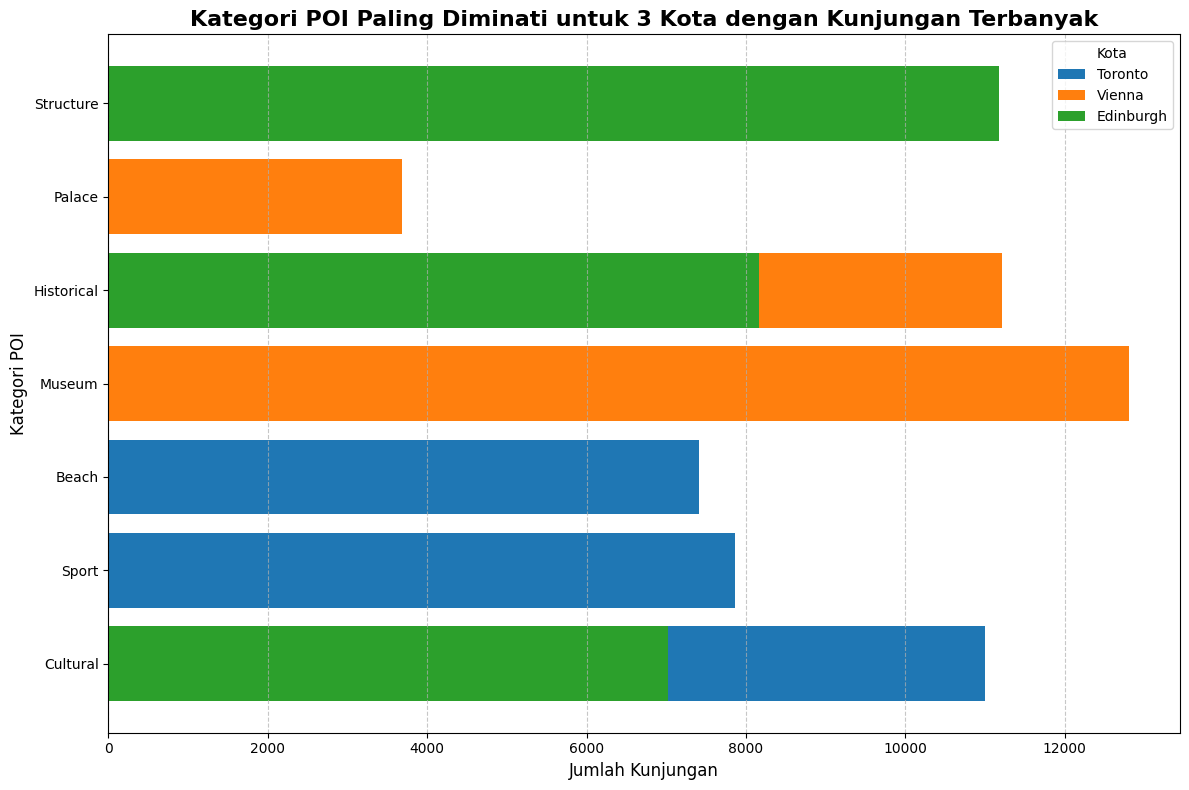

In [218]:
# Membuat visualisasi
plt.figure(figsize=(12, 8))

# Iterasi untuk setiap kota di daftar 3 kota teratas
for city in top_3_cities:
    # Ambil data khusus untuk kota tertentu
    city_data = top_themes_per_city[top_themes_per_city['city'] == city]

    # Buat bar horizontal untuk kategori POI dan jumlah kunjungan
    plt.barh(
        city_data['theme'],   # Nama kategori POI sebagai sumbu y
        city_data['poiFreq'], # Jumlah kunjungan sebagai sumbu x
        label=city            # Menambahkan label kota untuk legenda
    )

# Menambahkan judul grafik
plt.title("Kategori POI Paling Diminati untuk 3 Kota dengan Kunjungan Terbanyak", fontsize=16, weight="bold")

# Menambahkan label pada sumbu y dan sumbu x
plt.ylabel("Kategori POI", fontsize=12)
plt.xlabel("Jumlah Kunjungan", fontsize=12)

# Mengatur rotasi dan perataan label pada sumbu y agar mudah dibaca
plt.yticks(rotation=0, ha='right')

# Menambahkan legenda dengan judul "Kota" dan mengatur ukuran font
plt.legend(title="Kota", fontsize=10)

# Menambahkan padding otomatis untuk elemen visual agar tidak terpotong
plt.tight_layout()

# Menambahkan garis grid pada sumbu x untuk membantu membaca nilai
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

## Visualisasi 4 (Map)

In [219]:
# Memfilter 3 POI dengan jumlah kunjungan terbanyak untuk setiap Kota
top_poi_by_city = (
    POI_List.groupby(['city', 'poiName', 'lat', 'long', 'theme'])['poiFreq']
    .sum()
    .reset_index()
    .sort_values(['city', 'poiFreq'], ascending=[True, False])
    .groupby('city')
    .head(3)
)

top_poi_by_city

,city,poiName,lat,long,theme,poiFreq
21,Budapest,Matthias_Church,47.501940,19.034170,Cultural,1584
26,Budapest,Saint_Stephen's_Basilica,47.500833,19.053889,Cultural,1493
33,Budapest,Sándor_Palace,47.497800,19.037800,Historical,1020
55,Delhi,Qutb_complex,28.524382,77.185430,Architectural,709
46,Delhi,"Jama_Masjid,_Delhi",28.650700,77.233400,Religious,534
56,Delhi,Qutub_Minar,28.524355,77.185248,Architectural,418
70,Edinburgh,Edinburgh_Castle,55.948611,-3.200833,Historical,4569
91,Edinburgh,St_Giles'_Cathedral,55.949440,-3.190830,Cultural,4452
77,Edinburgh,National_Museum_of_Scotland,55.946940,-3.190000,Museum,3140
104,Glasgow,Glasgow_Central_railway_station,55.858000,-4.258000,Transport,1491


In [220]:
# Warna marker berdasarkan kategori POI
poi_category_colors = {
    "Cultural": "purple",
    "Historical": "black",
    "Architectural": "gray",
    "Religious": "lightblue",
    "Museum": "orange",
    "Transport": "blue",
    "Education": "red",
    "Park": "green",
    "Amusement": "yellow",
    "Beach": "pink",
}

# Membuat peta untuk setiap kota
city_maps = {}
for city, group in top_poi_by_city.groupby("city"):
    # Tentukan lokasi tengah kota
    location = [group["lat"].mean(), group["long"].mean()]

    # Membuat peta untuk kota
    m = folium.Map(location=location, zoom_start=12)

    # Menambahkan marker untuk setiap POI di kota tersebut
    for _, row in group.iterrows():
        category = row["theme"]
        poi_name = row["poiName"]
        folium.Marker(
            location=[row["lat"], row["long"]],
            popup=(f"<b>{poi_name}</b><br>"
                   f"Kunjungan: {row['poiFreq']}<br>"
                   f"Kategori: {category}"),
            icon=folium.Icon(color=poi_category_colors.get(category, "gray"))
        ).add_to(m)

    # Menambahkan legenda kategori POI
    legend_html = '''
    <div style="position: fixed;
                bottom: 20px; left: 20px; width: 200px; height: 250px;
                background-color: white; z-index:9999; font-size:14px;
                border:2px solid gray; padding: 10px;">
    <b>Legenda Kategori POI:</b><br>
    '''
    for cat, color in poi_category_colors.items():
        legend_html += f'<i style="background:{color}; width:12px; height:12px; display:inline-block;"></i> {cat}<br>'
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))

    # Simpan peta dalam dictionary berdasarkan kota
    city_maps[city] = m

    # Simpan peta sebagai file HTML
    m.save(f"top_3_poi_map_{city.lower().replace(' ', '_')}.html")

# Menampilkan nama file peta
city_maps

<ipython-input-220-a02412f6ff89>:33: UserWarning: color argument of Icon should be one of: {'lightblue', 'beige', 'blue', 'white', 'cadetblue', 'black', 'orange', 'darkpurple', 'gray', 'red', 'darkred', 'pink', 'lightred', 'darkgreen', 'lightgray', 'darkblue', 'lightgreen', 'green', 'purple'}.
  icon=folium.Icon(color=poi_category_colors.get(category, "gray"))


{'Budapest': <folium.folium.Map at 0x7de1d6926590>,
 'Delhi': <folium.folium.Map at 0x7de1d6924f40>,
 'Edinburgh': <folium.folium.Map at 0x7de1d6925ba0>,
 'Glasgow': <folium.folium.Map at 0x7de1d6950b50>,
 'Osaka': <folium.folium.Map at 0x7de1d6952140>,
 'Perth': <folium.folium.Map at 0x7de1d68d0dc0>,
 'Toronto': <folium.folium.Map at 0x7de1d68d1b70>,
 'Vienna': <folium.folium.Map at 0x7de1d68d0520>}

In [221]:
city_maps['Budapest']

In [222]:
city_maps['Delhi']

In [223]:
city_maps['Edinburgh']

In [224]:
city_maps['Glasgow']

In [225]:
city_maps['Osaka']

In [226]:
city_maps['Perth']

In [227]:
city_maps['Toronto']

In [228]:
city_maps['Vienna']